# Tahap 3 - Rule-Engine BOM (dekomposisi dimensi ke part list)

JSON dari model hanya berisi **dimensi global**. Tukang butuh **daftar lembaran**:
panel apa saja, ukuran berapa, berapa keping, tepi mana yang di-edging.

Modul [`bom_engine.py`](bom_engine.py) melakukan itu secara **deterministik** -
tanpa model, tanpa randomness, jadi hasilnya bisa diaudit dan diperdebatkan
dengan mandor.

### Aturan pengurangan sambungan

Konstruksi yang diasumsikan: **top & bottom menjepit dinding samping**, plinth di bawah.

```
tinggi dinding samping = tinggi total - tebal top - tebal bottom - tinggi plinth
lebar ambalan          = panjang total - 2 x tebal samping
ukuran potong          = ukuran jadi - tebal edging (per sisi yang di-edging)
```

### Konvensi `eb`

`eb = [top, right, bottom, left]`. Sisi *top/bottom* sepanjang `length_mm`,
sisi *left/right* sepanjang `width_mm`. Karena itu edging pada sisi kiri/kanan
mengurangi **panjang** potong, dan edging atas/bawah mengurangi **lebar** potong.

## 1. Muat modul & satu sampel

In [1]:
from pathlib import Path
import json, sys

BASE_DIR = Path.cwd()
sys.path.insert(0, str(BASE_DIR))

DATA_DIR = BASE_DIR / "dataset_generator" / "synthetic_furniture_dataset_v2"
GT_DIR   = DATA_DIR / "ground_truth"

import bom_engine as bom
from schema import FurnitureBOMData, parse_model_output
from importlib import reload
reload(bom)

SAMPLE_ID = "synth_0001"
spec_raw  = (GT_DIR / f"{SAMPLE_ID}.json").read_text(encoding="utf-8")
spec      = parse_model_output(spec_raw)

print(json.dumps(spec.model_dump(), indent=2))

{
  "furniture_type": "base_cabinet",
  "overall_dimensions": {
    "length_cm": 63.0,
    "width_cm": 54.1,
    "height_cm": 78.3
  },
  "plinth": {
    "has_plinth": true,
    "height_cm": 8.0,
    "offset_cm": 3.0
  },
  "partitions": {
    "shelves_count": 3,
    "doors_count": 3,
    "drawers_count": 1
  },
  "material": {
    "board_material": "Plywood",
    "board_thickness_mm": 15,
    "finish": "HPL",
    "finish_color": "Abu",
    "finish_code": "TH 716 AC"
  },
  "drop_pocket": null,
  "has_curve": false,
  "default_thickness_mm": 18,
  "default_edging_mm": 1.0
}


## 2. Hitung part list

`BOMConfig` memuat aturan bengkel yang bisa diputar tanpa menyentuh logika:
tebal panel belakang, setback ambalan, celah pintu, tinggi muka laci, dan
clearance rel laci.

In [2]:
cfg = bom.BOMConfig()
print(json.dumps(cfg.__dict__, indent=2))

parts = bom.build_bom(spec, cfg)

import pandas as pd
df = pd.DataFrame([p.to_dict() for p in parts])
df["eb"] = df["eb"].apply(lambda e: "".join(str(x) for x in e))
display(df[["part_name", "length_mm", "width_mm", "thickness_mm", "qty", "eb",
            "cut_length_mm", "cut_width_mm", "material", "grain_locked", "notes"]])

print(json.dumps(bom.bom_summary(parts), indent=2))

{
  "back_panel_thickness_mm": 4,
  "shelf_setback_mm": 20,
  "door_gap_mm": 3.0,
  "drawer_front_height_mm": 150.0,
  "drawer_slide_clearance_mm": 13.0,
  "drawer_box_height_reduction_mm": 30.0,
  "drawer_depth_reduction_mm": 50.0,
  "drawer_bottom_thickness_mm": 9,
  "edging_on_hidden_edges": false
}


,part_name,length_mm,width_mm,thickness_mm,qty,eb,cut_length_mm,cut_width_mm,material,grain_locked,notes
0,Side Panel,673,541,15,2,0100,672,541,Plywood 15mm,True,tepi depan di-edging
1,Top Panel,630,541,15,1,0010,630,540,Plywood 15mm,True,tepi depan di-edging
2,Bottom Panel,630,541,15,1,0010,630,540,Plywood 15mm,True,tepi depan di-edging
3,Shelf,600,517,15,3,0010,600,516,Plywood 15mm,True,tepi depan di-edging
4,Back Panel,630,703,4,1,0000,630,703,Plywood 4mm,False,dipaku/overlay di belakang carcass
5,Plinth Side Rail,511,80,15,2,0000,511,80,Plywood 15mm,False,
6,Plinth Front/Back Rail,600,80,15,2,0000,600,80,Plywood 15mm,False,rail depan mundur 30 mm dari muka
7,Drawer Front,624,150,15,1,1111,622,148,Plywood 15mm,True,"muka laci, seluruh sisi di-edging"
8,Drawer Box Side,491,120,15,2,1000,491,119,Plywood 15mm,True,
9,Drawer Box Front/Back,568,120,15,2,1000,568,119,Plywood 15mm,True,


{
  "part_types": 12,
  "total_pieces": 21,
  "area_m2_by_thickness": {
    "4": 0.443,
    "9": 0.262,
    "15": 3.202
  },
  "edging_length_m": 12.31
}


## 3. Bedah aritmatikanya

Jangan percaya part list yang tidak bisa dijelaskan. Cell ini menghitung ulang
angka-angka kunci dengan tangan dan membandingkannya dengan output engine.

In [3]:
t   = float(spec.material.board_thickness_mm or spec.default_thickness_mm)
eb_ = float(spec.default_edging_mm)
L   = spec.overall_dimensions.length_cm * 10
D   = spec.overall_dimensions.width_cm * 10
H   = spec.overall_dimensions.height_cm * 10
ph  = spec.plinth.height_cm * 10 if spec.plinth.has_plinth else 0.0

side_h    = H - ph - 2 * t
shelf_len = L - 2 * t

print(f"tebal papan        t = {t:.1f} mm   (dari material.board_thickness_mm)")
print(f"panjang total      L = {L:.1f} mm")
print(f"kedalaman          D = {D:.1f} mm")
print(f"tinggi total       H = {H:.1f} mm")
print(f"tinggi plinth     ph = {ph:.1f} mm\n")
print(f"tinggi samping = {H:.0f} - {ph:.0f} - 2 x {t:.0f} = {side_h:.0f} mm")
print(f"lebar ambalan  = {L:.0f} - 2 x {t:.0f} = {shelf_len:.0f} mm\n")

by_name = {p.part_name: p for p in parts}
assert by_name["Side Panel"].length_mm == round(side_h), "tinggi samping tidak cocok"
if "Shelf" in by_name:
    assert by_name["Shelf"].length_mm == round(shelf_len), "lebar ambalan tidak cocok"

print("Kompensasi edging (ukuran jadi -> ukuran potong):")
for p in parts:
    dl = p.length_mm - p.cut_length_mm
    dw = p.width_mm - p.cut_width_mm
    if dl or dw:
        print(f"  {p.part_name:<24} eb={p.eb}  panjang -{dl} mm, lebar -{dw} mm "
              f"(tebal edging {eb_} mm)")

tebal papan        t = 15.0 mm   (dari material.board_thickness_mm)
panjang total      L = 630.0 mm
kedalaman          D = 541.0 mm
tinggi total       H = 783.0 mm
tinggi plinth     ph = 80.0 mm

tinggi samping = 783 - 80 - 2 x 15 = 673 mm
lebar ambalan  = 630 - 2 x 15 = 600 mm

Kompensasi edging (ukuran jadi -> ukuran potong):
  Side Panel               eb=[0, 1, 0, 0]  panjang -1 mm, lebar -0 mm (tebal edging 1.0 mm)
  Top Panel                eb=[0, 0, 1, 0]  panjang -0 mm, lebar -1 mm (tebal edging 1.0 mm)
  Bottom Panel             eb=[0, 0, 1, 0]  panjang -0 mm, lebar -1 mm (tebal edging 1.0 mm)
  Shelf                    eb=[0, 0, 1, 0]  panjang -0 mm, lebar -1 mm (tebal edging 1.0 mm)
  Drawer Front             eb=[1, 1, 1, 1]  panjang -2 mm, lebar -2 mm (tebal edging 1.0 mm)
  Drawer Box Side          eb=[1, 0, 0, 0]  panjang -0 mm, lebar -1 mm (tebal edging 1.0 mm)
  Drawer Box Front/Back    eb=[1, 0, 0, 0]  panjang -0 mm, lebar -1 mm (tebal edging 1.0 mm)
  Door             

## 4. Output JSON siap konsumsi API

Format inilah yang nanti dikirim ke layanan lain (nesting, penawaran harga, WO bengkel).

In [4]:
payload = [p.to_dict() for p in parts]
print(json.dumps(payload[:4], indent=2))

OUT_JSON = BASE_DIR / "outputs" / f"bom_{SAMPLE_ID}.json"
OUT_JSON.parent.mkdir(parents=True, exist_ok=True)
OUT_JSON.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print(f"\n{len(parts)} jenis part / {sum(p.qty for p in parts)} keping -> {OUT_JSON}")

[
  {
    "part_name": "Side Panel",
    "length_mm": 673,
    "width_mm": 541,
    "thickness_mm": 15,
    "qty": 2,
    "eb": [
      0,
      1,
      0,
      0
    ],
    "material": "Plywood 15mm",
    "grain_locked": true,
    "notes": "tepi depan di-edging",
    "cut_length_mm": 672,
    "cut_width_mm": 541
  },
  {
    "part_name": "Top Panel",
    "length_mm": 630,
    "width_mm": 541,
    "thickness_mm": 15,
    "qty": 1,
    "eb": [
      0,
      0,
      1,
      0
    ],
    "material": "Plywood 15mm",
    "grain_locked": true,
    "notes": "tepi depan di-edging",
    "cut_length_mm": 630,
    "cut_width_mm": 540
  },
  {
    "part_name": "Bottom Panel",
    "length_mm": 630,
    "width_mm": 541,
    "thickness_mm": 15,
    "qty": 1,
    "eb": [
      0,
      0,
      1,
      0
    ],
    "material": "Plywood 15mm",
    "grain_locked": true,
    "notes": "tepi depan di-edging",
    "cut_length_mm": 630,
    "cut_width_mm": 540
  },
  {
    "part_name": "Shelf",
    "le

## 5. Sensitivitas terhadap aturan bengkel

Berapa besar pengaruh mengubah aturan? Berguna saat menegosiasikan standar dengan bengkel.

In [5]:
variants = {
    "default": bom.BOMConfig(),
    "tanpa panel belakang": bom.BOMConfig(back_panel_thickness_mm=0),
    "edging semua sisi": bom.BOMConfig(edging_on_hidden_edges=True),
    "celah pintu 2 mm": bom.BOMConfig(door_gap_mm=2.0),
    "muka laci 180 mm": bom.BOMConfig(drawer_front_height_mm=180.0),
}

rows_v = []
for name, c in variants.items():
    ps = bom.build_bom(spec, c)
    s = bom.bom_summary(ps)
    rows_v.append({"varian": name, "jenis part": s["part_types"], "keping": s["total_pieces"],
                   "luas m2": sum(s["area_m2_by_thickness"].values()),
                   "edging m": s["edging_length_m"]})
display(pd.DataFrame(rows_v).set_index("varian"))

,jenis part,keping,luas m2,edging m
varian,,,,
default,12,21,3.907,12.31
tanpa panel belakang,11,20,3.471,12.31
edging semua sisi,12,21,3.907,37.29
celah pintu 2 mm,12,21,3.912,12.34
muka laci 180 mm,12,21,3.971,12.19


## 6. Uji batch: apakah engine tahan seluruh dataset?

Rule engine harus tidak pernah menghasilkan ukuran negatif, part nol keping, atau
part yang lebih besar dari satu lembar triplek. Cell ini menjalankannya pada
seluruh ground truth dan menghitung **jumlah error** per jenis.

In [6]:
from collections import Counter

gt_files = sorted(GT_DIR.glob("*.json"))
errors = Counter()
oversized, negative, crashed = [], [], []
piece_counts, area_m2 = [], []

for f in gt_files:
    try:
        d = parse_model_output(f.read_text(encoding="utf-8"))
        ps = bom.build_bom(d)
    except Exception as e:
        errors[type(e).__name__] += 1
        crashed.append((f.stem, repr(e)[:120]))
        continue

    if not ps:
        errors["part_list_kosong"] += 1
        continue
    for p in ps:
        if p.cut_length_mm <= 0 or p.cut_width_mm <= 0:
            errors["ukuran_non_positif"] += 1
            negative.append((f.stem, p.part_name, p.cut_length_mm, p.cut_width_mm))
        if max(p.cut_length_mm, p.cut_width_mm) > 2440 or min(p.cut_length_mm, p.cut_width_mm) > 1220:
            errors["lebih_besar_dari_lembaran"] += 1
            oversized.append((f.stem, p.part_name, p.cut_length_mm, p.cut_width_mm))
    piece_counts.append(sum(p.qty for p in ps))
    area_m2.append(sum(p.area_mm2() for p in ps) / 1e6)

print(f"Sampel diproses     : {len(gt_files)}")
print(f"Sampel gagal        : {len(crashed)}")
print(f"Rincian error       : {dict(errors) or 'tidak ada'}")
print(f"Keping per furnitur : min {min(piece_counts)} / median "
      f"{sorted(piece_counts)[len(piece_counts)//2]} / max {max(piece_counts)}")
print(f"Luas papan (m2)     : min {min(area_m2):.2f} / max {max(area_m2):.2f}")

for label, lst in [("CRASH", crashed), ("UKURAN NEGATIF", negative), ("MELEBIHI LEMBARAN", oversized)]:
    if lst:
        print(f"\ncontoh {label} ({len(lst)}):")
        for row in lst[:5]:
            print("  ", row)

Sampel diproses     : 1500
Sampel gagal        : 0
Rincian error       : {'lebih_besar_dari_lembaran': 195}
Keping per furnitur : min 9 / median 14 / max 27
Luas papan (m2)     : min 1.14 / max 11.79

contoh MELEBIHI LEMBARAN (195):
   ('synth_0004', 'Back Panel', 1347, 1801)
   ('synth_0021', 'Back Panel', 1244, 1819)
   ('synth_0026', 'Back Panel', 1261, 1986)
   ('synth_0027', 'Back Panel', 1472, 2008)
   ('synth_0034', 'Back Panel', 1561, 1535)


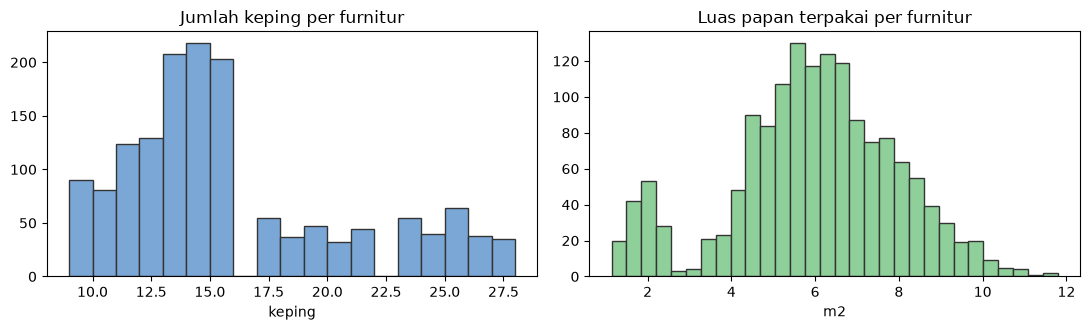

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(piece_counts, bins=range(min(piece_counts), max(piece_counts) + 2),
           color="#7ba7d7", edgecolor="#333")
ax[0].set_title("Jumlah keping per furnitur"); ax[0].set_xlabel("keping")
ax[1].hist(area_m2, bins=30, color="#8fcf9a", edgecolor="#333")
ax[1].set_title("Luas papan terpakai per furnitur"); ax[1].set_xlabel("m2")
plt.tight_layout(); plt.show()

## 7. Dari output model langsung ke part list

Di produksi, input engine bukan ground truth melainkan teks mentah model.
`bom_from_json` menangani pembersihan pagar ```` ```json ```` dan validasi skema sekaligus.

In [8]:
raw_model_output = "```json\n" + spec_raw + "\n```"     # simulasi output model
parts2 = bom.bom_from_json(raw_model_output)
print(f"{len(parts2)} jenis part dari teks mentah model")
print(json.dumps(bom.bom_summary(parts2), indent=2))

12 jenis part dari teks mentah model
{
  "part_types": 12,
  "total_pieces": 21,
  "area_m2_by_thickness": {
    "4": 0.443,
    "9": 0.262,
    "15": 3.202
  },
  "edging_length_m": 12.31
}
